# Local registration with ICP

In the RGBD folder we have the first 400 images from one of the datasets from: [http://redwood-data.org/indoor_lidar_rgbd/download.html](http://redwood-data.org/indoor_lidar_rgbd/download.html)

In [1]:
import open3d as o3d
import matplotlib.pyplot as plt
import numpy as np
import copy
        
# Helper function to draw registrations (reccomended)
def draw_registrations(source, target, transformation = None, recolor = False):
        source_temp = copy.deepcopy(source)
        target_temp = copy.deepcopy(target)
        if(recolor):
            source_temp.paint_uniform_color([1, 0.706, 0])
            target_temp.paint_uniform_color([0, 0.651, 0.929])
        if(transformation is not None):
            source_temp.transform(transformation)
        o3d.visualization.draw_geometries([source_temp, target_temp])

## Creating point clouds from image data
Now we are going to try to create our own point clouds from RGB+depth images.
First, we load two RGBD images.

In [2]:
# Read in images. We have images 000000 - 0000400
color_raw0 = o3d.io.read_image("RGBD/color/000000.jpg")
depth_raw0 = o3d.io.read_image("RGBD/depth/000000.png")

# color_raw1 = o3d.io.read_image("RGBD/color/000005.jpg")
# depth_raw1 = o3d.io.read_image("RGBD/depth/000005.png")
color_raw1 = o3d.io.read_image("RGBD/color/000300.jpg")
depth_raw1 = o3d.io.read_image("RGBD/depth/000300.png")

Create point clouds from rgb + depth images.

If you set `convert_rgb_to_intensity = False` you will retain the colors from the rgb image.

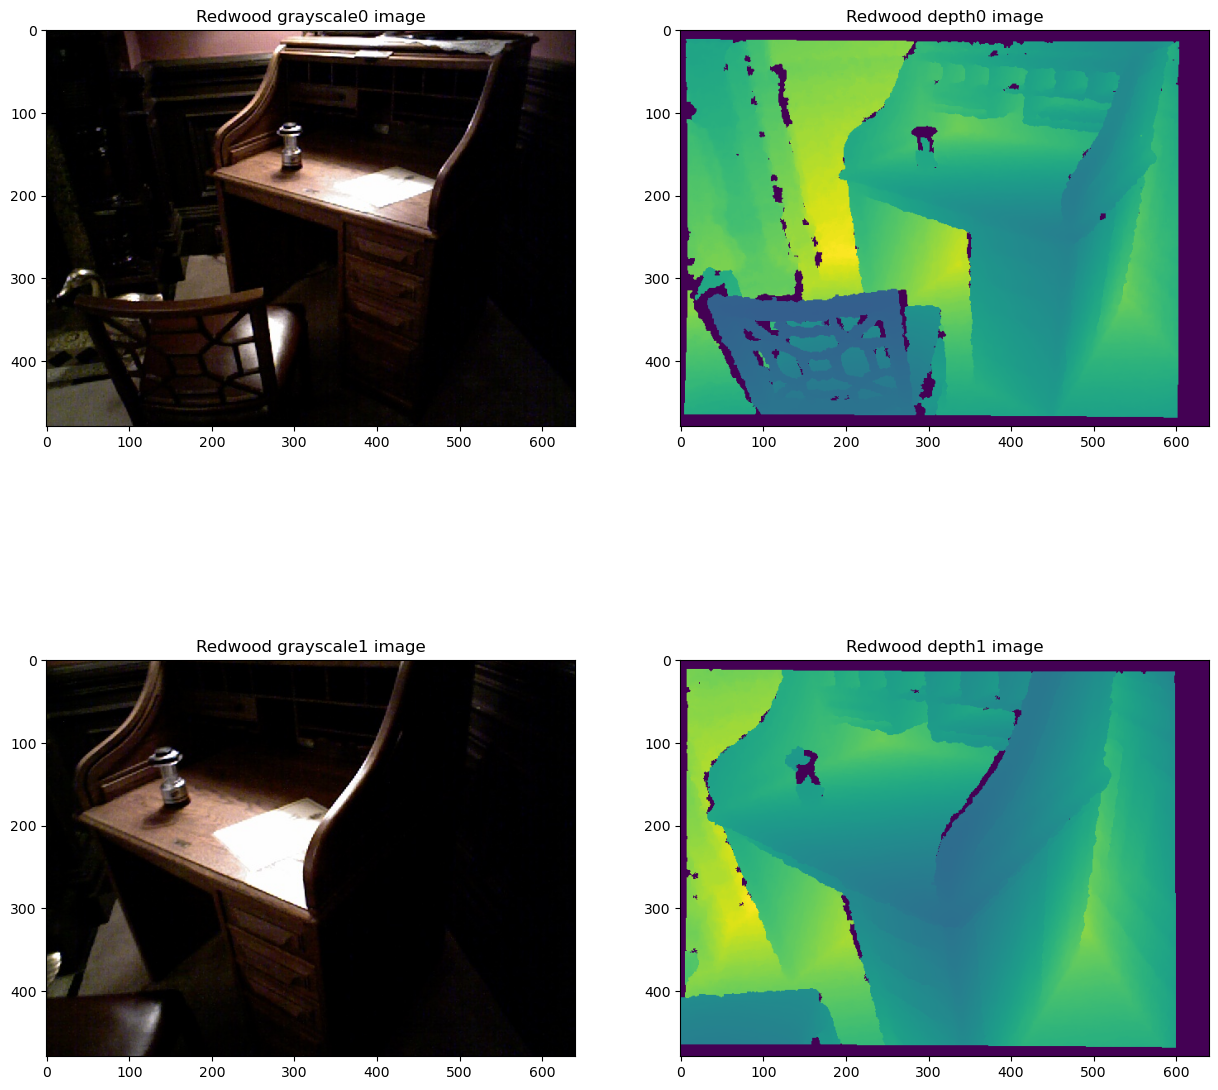

In [3]:
rgbd_image0 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw0, 
    depth_raw0, 
    convert_rgb_to_intensity = False)

rgbd_image1 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw1, 
    depth_raw1, 
    convert_rgb_to_intensity = False)

#show images
fig= plt.figure(figsize=(15,15))
plt.subplot(221)
plt.title('Redwood grayscale0 image')
plt.imshow(rgbd_image0.color)

plt.subplot(222)
plt.title('Redwood depth0 image')
plt.imshow(rgbd_image0.depth)

plt.subplot(223)
plt.title('Redwood grayscale1 image')
plt.imshow(rgbd_image1.color)

plt.subplot(224)
plt.title('Redwood depth1 image')
plt.imshow(rgbd_image1.depth)

plt.show()


## Images to point cloud
Now we create point clouds from the RGBD images we just loaded/created.


Here, we use `PinholeCameraIntrinsicParameters.PrimeSenseDefault` as default camera parameters. 

It has an image resolution of 640x480, focal length of ($f_x$, $f_y$) = (525.0, 525.0), and optical center ($c_x$, $c_y$) = (319.5, 239.5). 

An identity matrix is used as default extrinsic parameters. `pcd.transform` applies an up-down flip transformation on the point cloud for an improved visualization.


If execution becomes too slow you can downsample the point cloud.

In [4]:
# Source pointcloud
camera = o3d.camera.PinholeCameraIntrinsic(
        o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)

source = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image0, camera)

# Target pointcloud
target = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image1, camera)

# Flip it, otherwise the pointcloud will be upside down
source.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
target.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])

bbox = source.get_axis_aligned_bounding_box()
extent = bbox.get_extent()
max_extent = max(extent)
print("Extent:", extent)
print("Max extent:", max_extent)

voxel_size = 0.02 * max_extent

# Draw
# draw_registrations(source, target, recolor=True)


Extent: [2.22742761 1.6489419  1.86099994]
Max extent: 2.227427608058566


### Evaluation of pointclouds

Before we can run ICP, we evaluate our source and target point clouds. This gives us a feeling if we need a better initial transformation or not.
From (http://www.open3d.org/docs/latest/tutorial/Basic/icp_registration.html):

"The function `evaluate_registration` calculates two main metrics. 
- `fitness` measures the overlapping area (# of inlier correspondences / # of points in target). The higher the better. 
- `inlier_rmse` measures the RMSE of all inlier correspondences. The lower the better.

In [5]:
# Parameters
# threshold: ICP max correspondence distance (meters).
#   Too small → no matches; too large → wrong matches.
#   Indoor RGB-D: typically 0.02–0.10.
threshold = 0.2

# normal_radius: neighborhood size for estimating normals.
#   Too small → noisy normals; too large → oversmoothing.
#   Typically 2–5 × voxel_size (≈0.05–0.20 m indoors).
# normal_radius = voxel_size * 2
normal_radius = 0.15


# If we use image 0 and image 5 use this guess
# trans_init = np.asarray([
#     [1, 0, 0, 0],    # Translation in X
#     [0, 1, 0, 0],    # Translation in Y  
#     [0, 0, 1, 0],    # Translation in Z
#     [0, 0, 0, 1]
# ])

# If we use image 0 an image 300 use this guess
trans_init = np.asarray([
    [1, 0, 0, -0.25],    # Translation in X
    [0, 1, 0, -0.1],    # Translation in Y  
    [0, 0, 1, 0.4],    # Translation in Z
    [0, 0, 0, 1]
])

# Rotation if needed:
# rotation_angle = np.pi/6  # 30 degrees
# cos_a, sin_a = np.cos(rotation_angle), np.sin(rotation_angle)
# trans_init_manual = np.asarray([
#     [cos_a, -sin_a, 0, 0.1],
#     [sin_a,  cos_a, 0, 0.0],
#     [0,      0,     1, 0.2],
#     [0,      0,     0, 1]
# ])

#Evaluate registration
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, trans_init)
print(evaluation)

Initial alignment
RegistrationResult with fitness=7.250463e-01, inlier_rmse=7.787803e-02, and correspondence_set size of 189675
Access transformation to get result.


## ICP

Now try to call icp with your point clouds and your initial transformation.

Initially we use:
```Python
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()
icp_result = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_plane)
```

In [7]:
###
# ICP code here
###

point_to_point = o3d.pipelines.registration.TransformationEstimationPointToPoint()


icp_result = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init, point_to_point
)

draw_registrations(source, target, icp_result.transformation, True)

In [ ]:
icp_result.transformation

In [ ]:
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()
point_to_point = o3d.pipelines.registration.TransformationEstimationPointToPoint()

reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_point)

source.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=30),
    fast_normal_computation=True
)
target.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=30), 
    fast_normal_computation=True
)

icp_result_point_to_plane = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init, point_to_plane
)

icp_result_point_to_point = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init, point_to_point
)

# draw_registrations(source, target, icp_result_point_to_plane.transformation, True)

# Parameters
threshold = 0.02
trans_init = icp_result.transformation

#Evaluate registration
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(source, target, threshold, trans_init)
print(evaluation)

# Exersices

### A)
If you increase the amount of steps from the original image so from i.e. 000000.jpg<>000005.jpg to 00000.jpg<>000300.jpg, what happens?
### B)
Can you tweak the parameters `threshold` and `trans_init` to combat some of the ill effects that starts appearing?
### C)
Again try to use 
```Python
point_to_plane =  o3d.pipelines.registration.TransformationEstimationPointToPlane()

reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    point_to_plane)
```

This requires you to find the normals for each point cloud use:
```python
    source.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.5,
                            max_nn=30),fast_normal_computation=True)
```
Compare the resulting translations of the two methods. Is one better than the other?
### D)
Extend this and try to see how much of the bedroom you can reconstruct from the RGB and depth images.
You can extend a point cloud by `new = source + target`. Remember to resample the point cloud after a view additions so it does not get too large: `down_source = source.voxel_down_sample(voxel_size=0.05)`

In [9]:
import open3d as o3d
import numpy as np
import copy
import matplotlib.pyplot as plt

def draw_registrations(source, target, transformation=None, recolor=False):
    """
    Helper to visualize registration between two point clouds.

    - source, target: Open3D PointClouds
    - transformation: 4x4 matrix applied to source before drawing
    - recolor: if True, color source orange and target blue for clarity
    """
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    if recolor:
        source_temp.paint_uniform_color([1, 0.706, 0])      # orange-ish
        target_temp.paint_uniform_color([0, 0.651, 0.929])  # blue-ish
    if transformation is not None:
        source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])

# --- Camera model (intrinsics for RGB-D → point cloud) ---
camera = o3d.camera.PinholeCameraIntrinsic(
    o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault
)

# --- Parameters (tune these for quality vs. speed) ---
voxel_size       = 0.03   # Downsampling voxel size in meters.
                          # Smaller = denser model, larger = fewer points.
                          # Typical indoor RGB-D: 0.01–0.05 m.
threshold        = 0.1    # ICP max correspondence distance (meters).
                          # Too small → no matches; too large → wrong matches.
                          # Indoor RGB-D: ~0.02–0.10 m.
normal_radius    = 0.06   # Radius for normal estimation (meters).
                          # Recommended: 2–3 × voxel_size, e.g. 0.05–0.15 m.
frame_step       = 5      # Use every 5th frame: 000000, 000005, ...
last_frame_idx   = 400    # Last frame index to use (000300).
downsample_every = 5      # Downsample global model after every N fused frames.

# --- Helper: load one RGB-D frame and convert to a point cloud ---
def load_rgbd_pcd(idx):
    """
    Load RGB and depth images with index idx (e.g. 0 → 000000),
    create an RGBDImage, then back-project to a 3D point cloud.
    Also flips axes so the cloud is upright in Open3D's coordinate system.
    """
    fname = f"{idx:06d}"
    color_raw = o3d.io.read_image(f"RGBD/color/{fname}.jpg")
    depth_raw = o3d.io.read_image(f"RGBD/depth/{fname}.png")

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color_raw,
        depth_raw,
        convert_rgb_to_intensity=True  # convert RGB to grayscale intensity
    )

    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, camera)

    # Flip to right-handed, “upright” coordinate system (as in your original code):
    #  - Y and Z axes are inverted.
    pcd.transform([[1, 0, 0, 0],
                   [0,-1, 0, 0],
                   [0, 0,-1, 0],
                   [0, 0, 0, 1]])
    return pcd

# --- 1) Initialize global model with the first frame ---
start_idx = 0
global_pcd = load_rgbd_pcd(start_idx)

# Estimate normals on the initial global model (needed for point-to-plane ICP)
global_pcd.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=30),
    fast_normal_computation=True
)

# Not strictly needed here, but can be used if you track camera pose
T_global = np.eye(4)

# --- 2) Loop over subsequent frames and iteratively register them to the global model ---
frame_counter = 0

for idx in range(start_idx + frame_step, last_frame_idx + 1, frame_step):
    print(f"\n=== Registering frame {idx:06d} ===")

    # Load next RGB-D frame as a point cloud (this is the "source" for ICP)
    source = load_rgbd_pcd(idx)

    # Estimate normals for the source cloud (required for point-to-plane ICP)
    source.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=30)
    )

    # Initial guess for the transform between source and global model.
    # For consecutive frames, identity is usually a good start (camera moved only slightly).
    trans_init = np.eye(4)

    # Point-to-plane ICP: minimizes distance from source points to target planes (uses normals).
    point_to_plane = o3d.pipelines.registration.TransformationEstimationPointToPlane()

    icp_result = o3d.pipelines.registration.registration_icp(
        source,              # source (new frame)
        global_pcd,          # target (current global reconstruction)
        threshold,           # max correspondence distance
        trans_init,          # initial guess
        point_to_plane       # ICP error metric
    )

    print("ICP fitness:", icp_result.fitness, "RMSE:", icp_result.inlier_rmse)

    # Apply the ICP transform: bring the new frame into the global coordinate system
    source.transform(icp_result.transformation)

    # Fuse source into the global model (simple point cloud union)
    global_pcd += source

    # Periodically downsample the global point cloud so it doesn't explode in size
    frame_counter += 1
    if frame_counter % downsample_every == 0:
        global_pcd = global_pcd.voxel_down_sample(voxel_size)
        # Recompute normals after downsampling (points changed)
        global_pcd.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=30)
        )
        print(f"Downsampled global model to {len(global_pcd.points)} points")

# --- 3) Visualize reconstructed bedroom ---
# Optionally recolor to light gray so it’s easier to see than the default dark/patchy colors
global_pcd.paint_uniform_color([0.85, 0.85, 0.85])

o3d.visualization.draw_geometries([global_pcd])



=== Registering frame 000005 ===
ICP fitness: 0.9990449046420666 RMSE: 0.006881578660944865

=== Registering frame 000010 ===
ICP fitness: 1.0 RMSE: 0.005600593675884206

=== Registering frame 000015 ===
ICP fitness: 0.9999885497931329 RMSE: 0.004585264652002806

=== Registering frame 000020 ===
ICP fitness: 0.9999468377983254 RMSE: 0.004311862831401074

=== Registering frame 000025 ===
ICP fitness: 1.0 RMSE: 0.0036554784485919806
Downsampled global model to 12557 points

=== Registering frame 000030 ===
ICP fitness: 1.0 RMSE: 0.012079371783732824

=== Registering frame 000035 ===
ICP fitness: 0.9931367419193443 RMSE: 0.007340486615120717

=== Registering frame 000040 ===
ICP fitness: 1.0 RMSE: 0.004120475031472224

=== Registering frame 000045 ===
ICP fitness: 1.0 RMSE: 0.0052378690336650074

=== Registering frame 000050 ===
ICP fitness: 1.0 RMSE: 0.00693672054561644
Downsampled global model to 13698 points

=== Registering frame 000055 ===
ICP fitness: 1.0 RMSE: 0.013355166501069535